### Supernova distances and redshifts (part 1)


Measuring the cosmological relationship between distance and redshift is at the heart of the entire field of cosmology and allowed, among other things, the discovery of dark energy! At high redshifts, this is done with Type Ia Supernova which are standard (or better, standardizable) candles.

This is a [Nobel prize](https://www.nobelprize.org/prizes/physics/2011/riess/facts/) plot by [Riess et al](https://iopscience.iop.org/article/10.1086/300499) 

![Screen%20Shot%202022-05-01%20at%2010.48.48.png](attachment:Screen%20Shot%202022-05-01%20at%2010.48.48.png)

Let's recall the definition of magnitude and the distance modulus (ah! the astronomers...)

$$
\mu = m-M =  5 \log_{10}\left(\frac{d_L}{\rm pc}\right) - 5
$$

Here is the Hubble diagram for Type Ia supernovae (which are standard candels). The lines show the predictions for cosmologies with varying amounts of Ωm and ΩΛ. The o§bserved points all lie above the line for a universe with zero Λ. The lower panel, with the slope caused by the inverse square law taken out, shows the difference between the predictions more clearly and shows why a model with ΩΛ > 0 is favored. 

Supernovae Type la: esplosioni omogenee, circa la stessa luminosità intrinseca. sapendo quanta luce emettono possiamo capire quanto sono distanti da noi. \
Goal: misurare come varia la distanza degli oggetti celesti man mano che guardiamo indietro nel tempo


$\mu$ = distance modulus (misura logaritmica della distanza di un oggetto da noi. 
m = la luminosità che misuriamo dalla terra (magnitudine apparente)
M = la luminostà intrinseca della stella, ed è un valore conosciuto per le Supernovae Type la 
dL = distanza fisica dell'oggetto astronomico
pc = 1 parsec ovvero 3,26 anni luce
omega matter= la densità totale di materia nell'universo
omega lambda = la frazione di densità energetica associata all'energia oscura

Nel plot si vede che i modelli fittati stanno sopra ai modelli con omega lambda = 0, e in quelli sotto si vede che i residui si discostano da un valore lineare, posizionandosi dove lambda omega è > 0

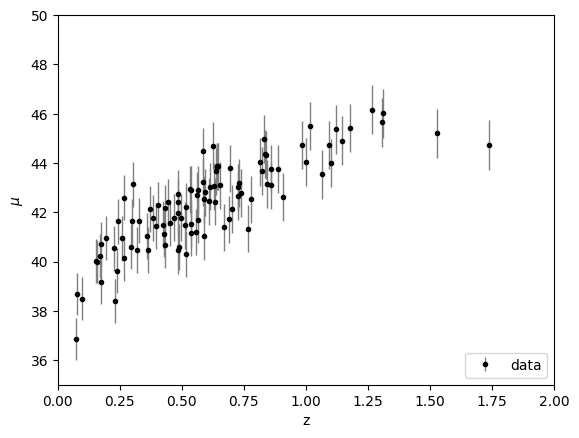

In [13]:
import pylab as plt
import numpy as np
import sklearn
import scipy
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS
z = np.linspace(0.01, 2, 1000)
z_sk = z_sample[:,np.newaxis]
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

####  Tasks

- First, explore fitting this data with the tecniques we have seen.
- Start from linear regression and polynomial regression
- For the case of  polynomial regression, just fit many of them for now.
- Let's bet based on intuition! Which fit is the best?
- In what cases are you underfitting the data?
- In what cases are you overfitting the data?
- Now split the data into training and validation sets
- Implement a cross-validation procedure
- Pick the best!
- Does it agree with our bets?

#### OPTIONAL
- Repeat with Basis Function Regression and Kernel Regression
- Explore what happens when you change the number of datapoints and plot the resulting learning curves.

39.60456481105869 [4.5911933]


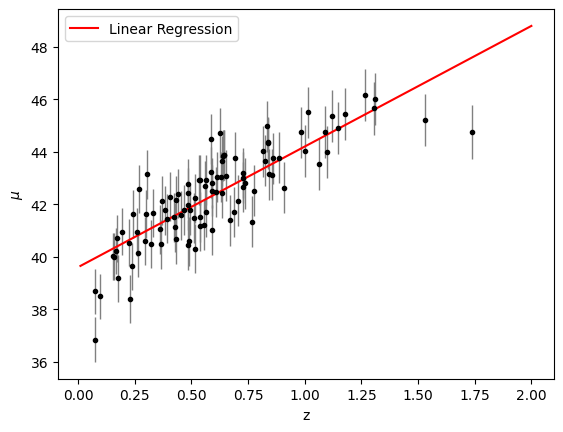

In [14]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(z_sk, mu_sample, dmu)

mu_lr = lin_reg.predict(z[:,np.newaxis])

theta0 = lin_reg.intercept_
theta1 = lin_reg.coef_

print(theta0, theta1)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)
plt.plot(z, mu_lr, '-r',label='Linear Regression')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend()

/home/lorenzo/Desktop/repos/python_ambient/lib/python3.12/site-packages/astroML/linear_model/linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


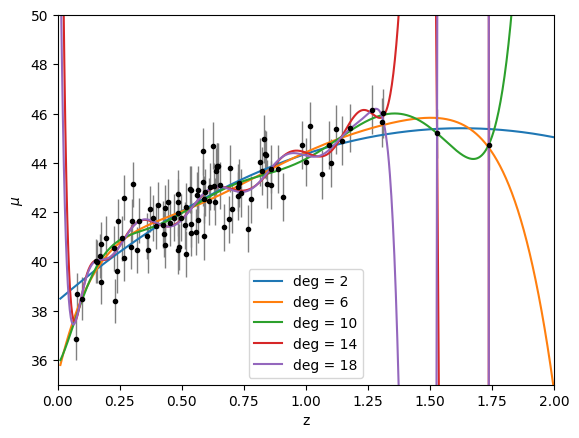

In [15]:
from astroML.linear_model import PolynomialRegression
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)

for deg in np.arange(1, 20)[1::4]:
    pol_reg = PolynomialRegression(deg)
    pol_reg.fit(z_sk, mu_sample, dmu)
    mu_pr = pol_reg.predict(z[:,np.newaxis])
    plt.plot(z, mu_pr,label=f"deg = {deg}", alpha = 1)
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.xlim(0,2)
plt.ylim(35,50);
plt.legend()

Il fit con 2 gradi sembra essere sensato mentre già con 6 gradi sembrerebbe esserci overfitting. Con 1 grado è underfitting, uguale a quello Lineare! Proseguiamo con il k-fold cross validation per decidere il grado del Polinomio

il degree che minimizza il validation error è: 5


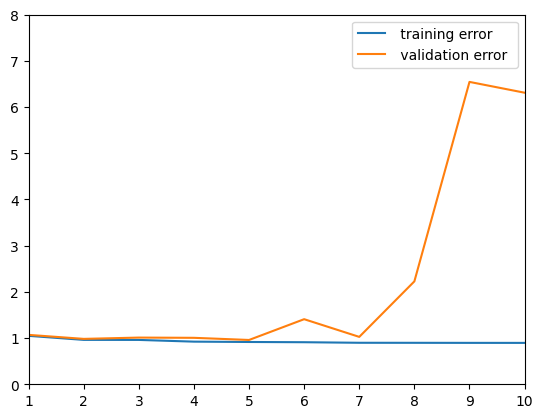

In [16]:
from sklearn.model_selection import KFold
degrees = np.arange(1, 11)
validation_errors = []
training_errors = []

#per comodità cambiamo i nomi alle variabili
X = z_sk
y = mu_sample
dy = dmu
#5-fold cv.
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for deg in degrees:
    fold_val_err = []
    fold_train_err = []
    
    for train_idx, val_idx in kf.split(X):
        
        #recuperiamo gli indici deiv alori
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        dy_train, dy_val = dy[train_idx], dy[val_idx]
        
        #fittiamo sul train 
        model = PolynomialRegression(deg)
        model.fit(X_train, y_train, dy_train)

    
        y_pred_train = model.predict(X_train)
        y_pred_val = model.predict(X_val)
        
        # calcoliamo gli errori (chi quadro)

        err_train = np.sqrt(np.mean(((y_train - y_pred_train) / dy_train) ** 2))
        err_val = np.sqrt(np.mean(((y_val - y_pred_val) / dy_val) ** 2))
        
        fold_train_err.append(err_train)
        fold_val_err.append(err_val)
        
    # salviamo la media sui 5 fold per il deg nello specifico
    training_errors.append(np.mean(fold_train_err))
    validation_errors.append(np.mean(fold_val_err))

plt.plot(degrees, training_errors, label = ' training error ' )
plt.plot(degrees, validation_errors, label = ' validation error ')
plt.xlim(1,10)
plt.ylim(0, 8)
best_deg = degrees[np.argmin(validation_errors)]
print(f"il degree che minimizza il validation error è: {best_deg}")
plt.legend()

Facciamo adesso con Kernel e Basis regression

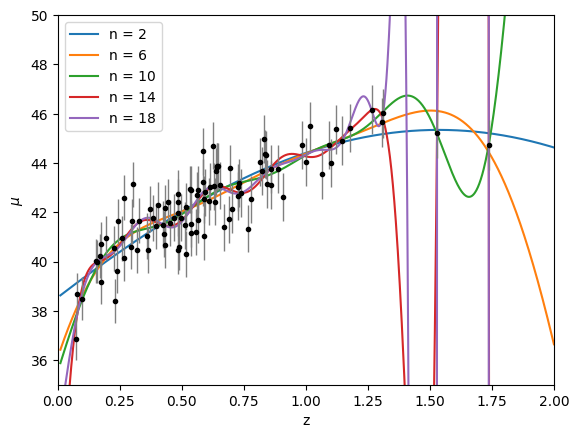

In [17]:
#BASIS
import astroML.linear_model
for n in np.arange(1,20)[1::4]:

    basis_mu = np.linspace(0,2,n)[:, None]
    basis_sigma = 1.0 * (basis_mu[1] - basis_mu[0])

    regressor = astroML.linear_model.BasisFunctionRegression('gaussian', mu=basis_mu, sigma=basis_sigma)
    regressor.fit(z_sample[:,np.newaxis], mu_sample, dmu)
    mu_fit = regressor.predict(z[:,np.newaxis])
   
    mu_fit = regressor.predict(z[:,np.newaxis])
    plt.plot(z, mu_fit,label=f"n = {n}")

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend()
plt.xlim(0,2)
plt.ylim(35,50);



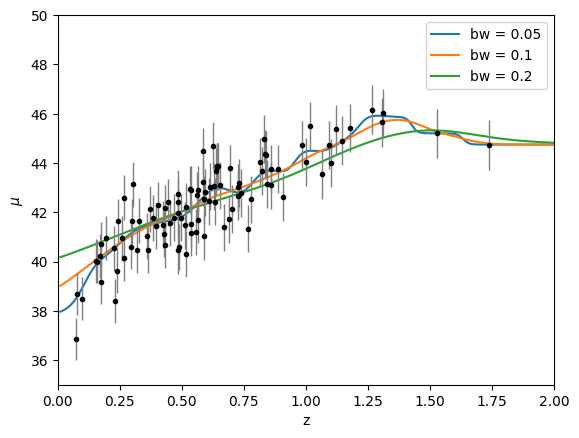

In [18]:
#Kernel Regression
bw_plot = [0.05, 0.10, 0.20]
for bw in bw_plot:

    regressor = astroML.linear_model.NadarayaWatson('gaussian', bw)
    regressor.fit(z_sample[:,np.newaxis], mu_sample, dmu)
    mu_fit = regressor.predict(z[:,np.newaxis])
   
    mu_fit = regressor.predict(z[:,np.newaxis])
    plt.plot(z, mu_fit,label=f"bw = {bw}")

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)
plt.xlabel("z")
plt.ylabel("$\mu$")

plt.xlim(0,2)
plt.legend()
plt.ylim(35,50);

il bw che minimizza il validation error è: 0.05


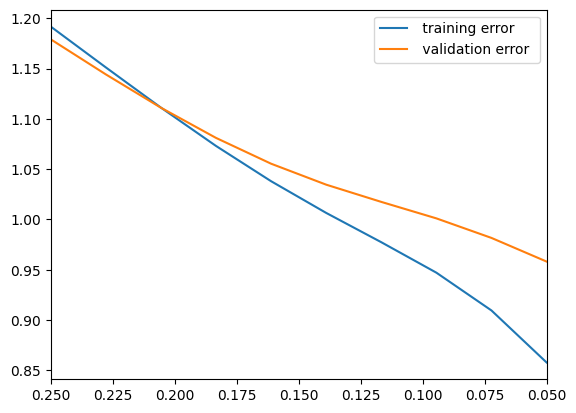

In [19]:
from sklearn.model_selection import KFold

validation_errors = []
training_errors = []

#per comodità cambiamo i nomi alle variabili
X = z_sk
y = mu_sample
dy = dmu
#5-fold cv.
kf = KFold(n_splits=10, shuffle=True, random_state=42)

bandwidths = np.linspace(0.05, 0.25, 10)
for bw in bandwidths:
    fold_val_err = []
    fold_train_err = []
    
    for train_idx, val_idx in kf.split(X):
        
        #recuperiamo gli indici deiv alori
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        dy_train, dy_val = dy[train_idx], dy[val_idx]
        
        #fittiamo sul train 
        model = astroML.linear_model.NadarayaWatson('gaussian', bw)
        model.fit(X_train, y_train, dy_train)

    
        y_pred_train = model.predict(X_train)
        y_pred_val = model.predict(X_val)
        
        # calcoliamo gli errori (chi quadro)

        err_train = np.sqrt(np.mean(((y_train - y_pred_train) / dy_train) ** 2))
        err_val = np.sqrt(np.mean(((y_val - y_pred_val) / dy_val) ** 2))
        
        fold_train_err.append(err_train)
        fold_val_err.append(err_val)
        
    # salviamo la media sui 5 fold per il deg nello specifico
    training_errors.append(np.mean(fold_train_err))
    validation_errors.append(np.mean(fold_val_err))

plt.plot(bandwidths, training_errors, label = ' training error ' )
plt.plot(bandwidths, validation_errors, label = ' validation error ')

plt.xlim(bandwidths[-1],bandwidths[0]) 
#plt.ylim(0, 8)
best_deg = bandwidths[np.argmin(validation_errors)]
print(f"il bw che minimizza il validation error è: {best_deg}")
plt.legend()

il degree che minimizza il validation error è: 5


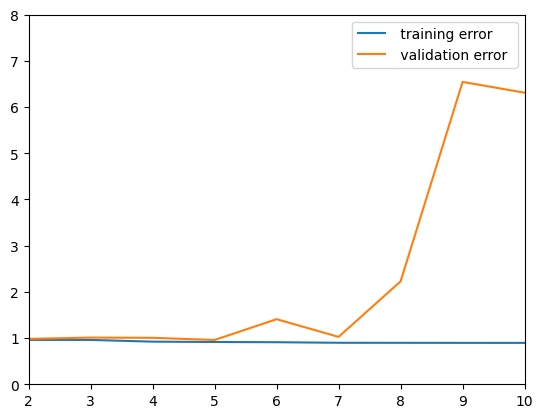

In [20]:
from sklearn.model_selection import KFold
degrees = np.arange(2, 11)
validation_errors = []
training_errors = []

#per comodità cambiamo i nomi alle variabili
X = z_sk
y = mu_sample
dy = dmu
#5-fold cv.
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for deg in degrees:
    fold_val_err = []
    fold_train_err = []
    
    for train_idx, val_idx in kf.split(X):
        
        #recuperiamo gli indici deiv alori
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        dy_train, dy_val = dy[train_idx], dy[val_idx]

        basis_mu = np.linspace(0,2,deg)[:, None]
        basis_sigma = 1.0 * (basis_mu[1] - basis_mu[0])

        regressor = astroML.linear_model.BasisFunctionRegression('gaussian', mu=basis_mu, sigma=basis_sigma)
        
        #fittiamo sul train 
        model = PolynomialRegression(deg)
        model.fit(X_train, y_train, dy_train)

    
        y_pred_train = model.predict(X_train)
        y_pred_val = model.predict(X_val)
        
        # calcoliamo gli errori (chi quadro)

        err_train = np.sqrt(np.mean(((y_train - y_pred_train) / dy_train) ** 2))
        err_val = np.sqrt(np.mean(((y_val - y_pred_val) / dy_val) ** 2))
        
        fold_train_err.append(err_train)
        fold_val_err.append(err_val)
        
    # salviamo la media sui 5 fold per il deg nello specifico
    training_errors.append(np.mean(fold_train_err))
    validation_errors.append(np.mean(fold_val_err))

plt.plot(degrees, training_errors, label = ' training error ' )
plt.plot(degrees, validation_errors, label = ' validation error ')
plt.xlim(2,10)
plt.ylim(0, 8)
best_deg = degrees[np.argmin(validation_errors)]
print(f"il degree che minimizza il validation error è: {best_deg}")
plt.legend()

[41.6361725  43.85304855 42.425679   44.96472492 43.66317337 41.0385854
 40.47572333 43.12308097 45.64726282 44.02852206 41.50167538 42.92901192
 42.12960007 42.78840966 42.15345413 43.20734785 42.91403402 38.48935111
 44.02200845 45.49348403 41.12442734 42.43426496 40.95384945 40.67303793
 45.41974758 41.38412117 41.57489699 44.35631529 41.44279219 42.52080021
 44.73365314 40.44836116 43.73973073 40.93682681 43.00695644 42.65197548
 40.47569605 44.90728053 40.58123887 44.73434708 39.18782683 40.60774377
 39.99757862 43.77679993 43.02875083 42.7005633  40.01713479 44.47341077
 42.29166558 41.52310588 38.39741027 44.69697233 41.03100827 38.68032347
 43.65443054 43.99305977 44.31984612 44.74532937 46.01542876 43.13336621
 42.12725671 43.86382122 42.22043135 43.13342988 42.39951315 40.2189722
 41.78001517 45.20348446 41.63584333 39.62962917 41.33982132 42.45204301
 41.47045908 40.53942813 41.66362237 43.54157458 41.78066489 41.69520148
 36.846956   41.76398102 42.75984556 43.04804394 45.3

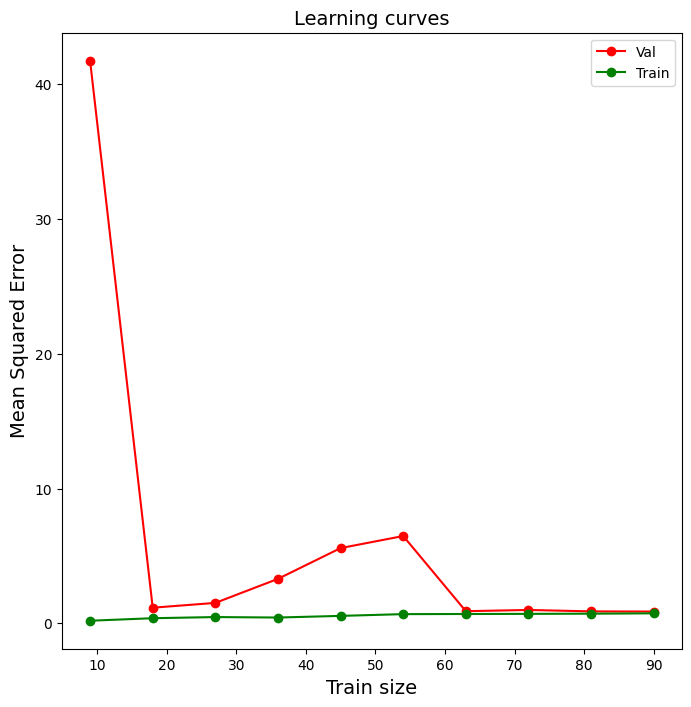

In [21]:
#LEARNING CURVES FOR POLYNOMIAL
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve

X = z_sample[:,np.newaxis]
y = mu_sample
print(y)
scaler = StandardScaler()
Xscaled = scaler.fit_transform(X)

pol_reg = PolynomialRegression(5)
# Ten training sample sizes from 10% to 100%
train_sizes, train_scores_linreg, test_scores_linreg = \
    learning_curve(pol_reg, Xscaled, y, train_sizes=np.linspace(0.1, 1, 10), \
    scoring="neg_mean_squared_error", cv=10)

fig = plt.figure(figsize=(8, 8))

plt.plot(train_sizes, -test_scores_linreg.mean(1), 'o-', color="r", label="Val")
plt.plot(train_sizes, -train_scores_linreg.mean(1), 'o-', color="g", label="Train")
                   
plt.xlabel("Train size",fontsize=14)
plt.ylabel("Mean Squared Error",fontsize=14)
plt.title('Learning curves',fontsize=14)
plt.legend(loc="best");

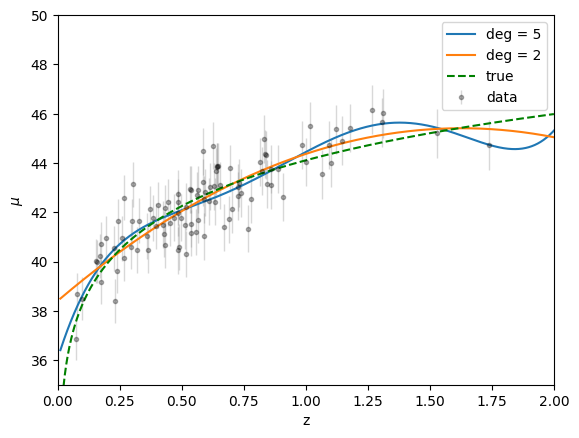

In [22]:
from astropy.cosmology import LambdaCDM
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data', alpha = 0.3)
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);
pol_reg = PolynomialRegression(5)
pol_reg.fit(z_sk, mu_sample, dmu)
mu_pr = pol_reg.predict(z[:,np.newaxis])
plt.plot(z, mu_pr,label=f"deg = {5}", alpha = 1)

pol_reg = PolynomialRegression(2)
pol_reg.fit(z_sk, mu_sample, dmu)
mu_pr = pol_reg.predict(z[:,np.newaxis])
plt.plot(z, mu_pr,label=f"deg = {2}", alpha = 1)


cosmo = LambdaCDM(H0=71, Om0=0.27, Ode0=1-0.27)
z = np.linspace(0.01, 2, 1000)
mu_true = cosmo.distmod(z)


plt.plot(z, mu_true, '--', c='green',label='true')

plt.legend()

### Part 2 

First let's fit our supernova synthetic data from last time using GPR.

- The key ingredient in getting a good GPR fit is the choice of the kernel and its parameters.
- Radial-basis function kernel (aka squared-exponential kernel) is a standard choice in the GPR world.
- But check out what's available in the `kernels` submodule of [sklearn.gaussian_process](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.gaussian_process)
- Plot the expectation value of the fit as well as the resulting 1-$\sigma$ and 2-$\sigma$ contours.
- Interpret the results.

*Note*. To start with, feel free to tweak the hyperparameters manually. But, of course, a publication-quality result will require a cross-validation analysis.

The European Space Agency is considering new cosmology-related space mission. They ask you to figure out what science you can do with 10 times more measurement compared to what you have right now. That is: you want to clone your data. We've seen this earlier in the class, but now we can do much much better.
- Think about the pdf of these data in $z$.
- Using your GPR fit, generate a set of $\mu$ measurements that respects the statistical properties of the data you were given. 

In [23]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS
z = np.linspace(0.01, 2, 1000)
z_sk = z_sample[:,np.newaxis]


In [24]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from sklearn.model_selection import KFold
#definiamo un kernel https://scikit-learn.org/stable/auto_examples/gaussian_process/plot_gpr_noisy_targets.html


kernel = 1 * RBF(length_scale=0.1, length_scale_bounds=(1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=dmu ** 2, normalize_y=True, n_restarts_optimizer=10)
gp.fit(z_sk,mu_sample)
y_pred, dy_pred = gp.predict(z_sk, return_std=True)
#print(y_pred, dy_pred)

[0.23946726 0.21041199 0.19706654 0.24950324 0.24746123 0.21463561
 0.21377362 0.25634329 0.49155195 0.30492087 0.20110904 0.19849115
 0.22102254 0.22746158 0.19999    0.20299329 0.19859845 0.4058242
 0.24487478 0.3118007  0.20044889 0.20945185 0.31068341 0.20010854
 0.39697828 0.21504025 0.19821139 0.25082654 0.2062575  0.20369024
 0.29855106 0.19707889 0.2564655  0.26179708 0.22549336 0.22556634
 0.22953515 0.37687245 0.1970446  0.34720557 0.32669362 0.24241433
 0.34185302 0.21932056 0.20670805 0.20055125 0.3473619  0.20301661
 0.20439319 0.19859237 0.28133271 0.20832772 0.20346884 0.4319438
 0.20974057 0.35193206 0.25154522 1.01493137 0.4951765  0.2521296
 0.2119127  0.21082452 0.19755812 0.23783602 0.19908712 0.33360524
 0.1970621  0.72099853 0.27341282 0.27632788 0.23412691 0.20582118
 0.19737788 0.28467302 0.22619128 0.33303548 0.19744098 0.20074876
 0.43465281 0.20896092 0.19707287 0.20900042 0.36304578 0.21094621
 0.22589059 0.25855061 0.23628244 0.27110785 0.21216117 0.1970625

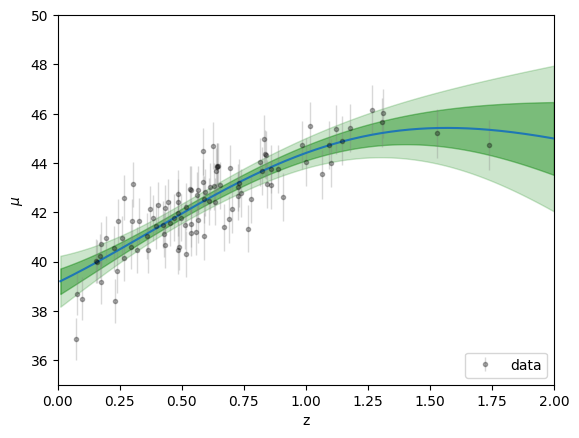

In [25]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data', alpha = 0.3)

mu_fit, sigma = gp.predict(z[:,np.newaxis], return_std=True)
print(dy_pred)
plt.plot(z, mu_fit)
plt.fill_between(z, mu_fit - sigma, mu_fit + sigma, alpha = 0.4, color = 'g')
plt.fill_between(z, mu_fit - 2*sigma, mu_fit + 2*sigma, alpha = 0.2, color = 'g')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);
plt.show()

Proviamo a cross-validare la length scale del kernel. Prima con l'optimizer di GPR attivo, mi aspetto che i grafici di errore di CV siano piatti perché la funzione GPR "aggiusta il tiro", poi lo facciamo con Optimizer Off.

In [26]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
X = z_sk
y = mu_sample
dy = dmu

# Le length scale del Kernel, gli iperparametri che vogliamo testare
ls_grid = np.linspace(0.01, 0.5, 10)

cv_training_errors = []
cv_validation_errors = []

for initial_ls in ls_grid:
    fold_train_err = []
    fold_val_err = []
    
    for train_idx, val_idx in kf.split(X):
        
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        dy_train, dy_val = dy[train_idx], dy[val_idx]
        
        
        kernel = 1 * RBF(length_scale=initial_ls)
        
        
        gp_cv = GaussianProcessRegressor(kernel=kernel, alpha=dy_train**2, normalize_y=True, n_restarts_optimizer=5, random_state=42)
        

        gp_cv.fit(X_train, y_train)

        pred_train = gp_cv.predict(X_train)
        pred_val = gp_cv.predict(X_val)
        

        err_train = np.sqrt(np.mean(((y_train - pred_train) / dy_train) ** 2))
        err_val = np.sqrt(np.mean(((y_val - pred_val) / dy_val) ** 2))
        
        fold_train_err.append(err_train)
        fold_val_err.append(err_val)
        
    cv_training_errors.append(np.mean(fold_train_err))
    cv_validation_errors.append(np.mean(fold_val_err))


best_ls = ls_grid[np.argmin(cv_validation_errors)]
print(best_ls)

0.33666666666666667


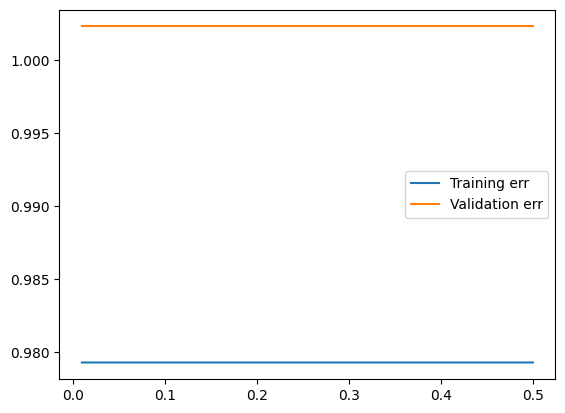

In [27]:
plt.plot(ls_grid, cv_training_errors, label ='Training err')
plt.plot(ls_grid, cv_validation_errors, label = 'Validation err')
plt.legend()

In [28]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
X = z_sk
y = mu_sample
dy = dmu

# Le length scale del Kernel, gli iperparametri che vogliamo testare
ls_grid = np.linspace(0.01, 0.5, 10)

cv_training_errors = []
cv_validation_errors = []

for initial_ls in ls_grid:
    fold_train_err = []
    fold_val_err = []
    
    for train_idx, val_idx in kf.split(X):
        
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        dy_train, dy_val = dy[train_idx], dy[val_idx]
        
        
        kernel = 1 * RBF(length_scale=initial_ls)
        
        
        gp_cv = GaussianProcessRegressor(kernel=kernel, alpha=dy_train**2, normalize_y=True,optimizer=None)
        

        gp_cv.fit(X_train, y_train)

        pred_train = gp_cv.predict(X_train)
        pred_val = gp_cv.predict(X_val)
        

        err_train = np.sqrt(np.mean(((y_train - pred_train) / dy_train) ** 2))
        err_val = np.sqrt(np.mean(((y_val - pred_val) / dy_val) ** 2))
        
        fold_train_err.append(err_train)
        fold_val_err.append(err_val)
        
    cv_training_errors.append(np.mean(fold_train_err))
    cv_validation_errors.append(np.mean(fold_val_err))


best_ls = ls_grid[np.argmin(cv_validation_errors)]
print(best_ls)

0.3911111111111111


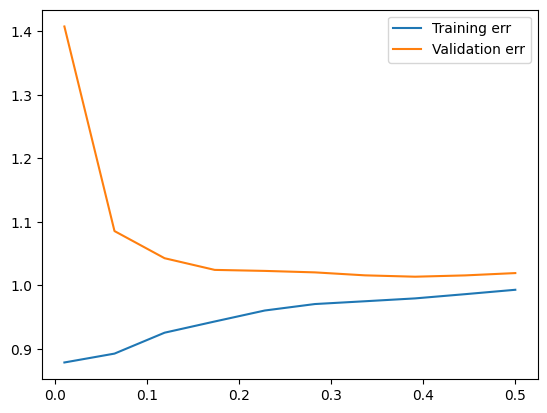

In [29]:
plt.plot(ls_grid, cv_training_errors, label ='Training err')
plt.plot(ls_grid, cv_validation_errors, label = 'Validation err')
plt.legend()

[0.23946726 0.21041199 0.19706654 0.24950324 0.24746123 0.21463561
 0.21377362 0.25634329 0.49155195 0.30492087 0.20110904 0.19849115
 0.22102254 0.22746158 0.19999    0.20299329 0.19859845 0.4058242
 0.24487478 0.3118007  0.20044889 0.20945185 0.31068341 0.20010854
 0.39697828 0.21504025 0.19821139 0.25082654 0.2062575  0.20369024
 0.29855106 0.19707889 0.2564655  0.26179708 0.22549336 0.22556634
 0.22953515 0.37687245 0.1970446  0.34720557 0.32669362 0.24241433
 0.34185302 0.21932056 0.20670805 0.20055125 0.3473619  0.20301661
 0.20439319 0.19859237 0.28133271 0.20832772 0.20346884 0.4319438
 0.20974057 0.35193206 0.25154522 1.01493137 0.4951765  0.2521296
 0.2119127  0.21082452 0.19755812 0.23783602 0.19908712 0.33360524
 0.1970621  0.72099853 0.27341282 0.27632788 0.23412691 0.20582118
 0.19737788 0.28467302 0.22619128 0.33303548 0.19744098 0.20074876
 0.43465281 0.20896092 0.19707287 0.20900042 0.36304578 0.21094621
 0.22589059 0.25855061 0.23628244 0.27110785 0.21216117 0.1970625

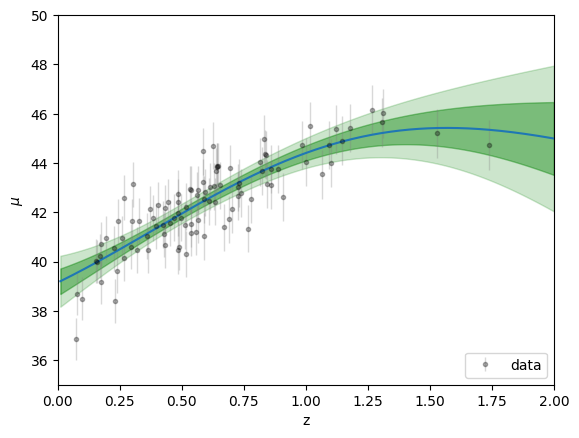

In [30]:
kernel = 1 * RBF(length_scale=best_ls)
gp = GaussianProcessRegressor(kernel=kernel, alpha=dmu ** 2, normalize_y=True)
gp.fit(z_sk,mu_sample)
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data', alpha = 0.3)

mu_fit, sigma = gp.predict(z[:,np.newaxis], return_std=True)
print(dy_pred)
plt.plot(z, mu_fit)
plt.fill_between(z, mu_fit - sigma, mu_fit + sigma, alpha = 0.4, color = 'g')
plt.fill_between(z, mu_fit - 2*sigma, mu_fit + 2*sigma, alpha = 0.2, color = 'g')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);
plt.show()

The European Space Agency is considering new cosmology-related space mission. They ask you to figure out what science you can do with 10 times more measurement compared to what you have right now. That is: you want to clone your data. We've seen this earlier in the class, but now we can do much much better.
- Think about the pdf of these data in $z$.
- Using your GPR fit, generate a set of $\mu$ measurements that respects the statistical properties of the data you were given. 

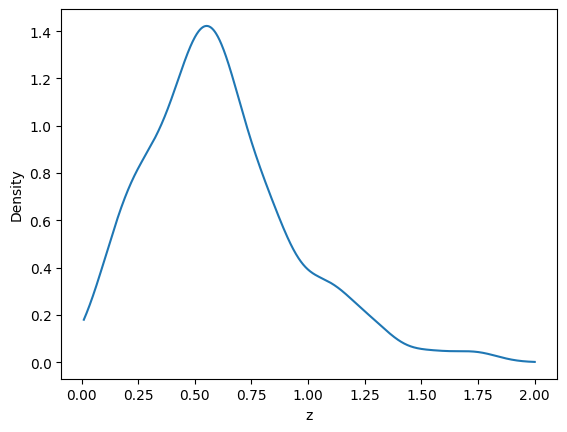

In [31]:
#Cloniamo i dati con una density Estimation KDE
from sklearn.neighbors import KernelDensity
kde = KernelDensity(kernel='gaussian', bandwidth = 0.1).fit(z_sk)
log_pdf = kde.score_samples(z[:,np.newaxis])
pdf = np.exp(log_pdf)
plt.plot(z, pdf)
plt.xlabel('z')
plt.ylabel('Density')
plt.show()

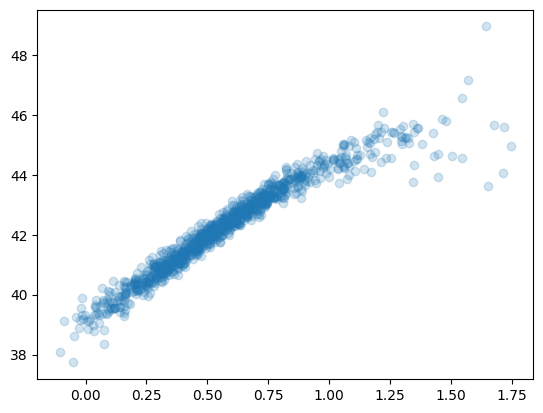

In [32]:
#Usiamo la KDE per creare nuovi dati e poi il fit della GPR per trovare i rispettivi valori di y
N = int(1e3)
kde_z_samples = kde.sample(N)
mu_fitted = []
for z in kde_z_samples:
    mu_fit, sigma = gp.predict(z[:,np.newaxis], return_std=True)
    #il dato fittato dalla GPR ha un'incertezza e dunque il valore che appendiamo all'array deve essere estratto da una normmale cnetrata nel punto
    mu_fitted.append(np.random.normal(mu_fit, sigma))

plt.scatter(kde_z_samples, mu_fitted, alpha = 0.2)

### Part 3 


We now have a suite of **data-driven** predictive models for our supernova dataset (from polynomials to GPR). That is: we can faithfully predict how a future redshift/distance measurement will look like given the current sample.

This is already great and these kind of tools are immensely useful in a variety of contexts (also involving a lot of money: suppose you want to predict how much a give financial asset will perform on tomorrow's stock market... You  might not really care about expressing the underlying financial model in simple terms, as long as your investments are profitable).

For the case of supernovae, however, we have do have physical theory which is $\Lambda$CDM. We can do a **parametric** fit (and hopehully by now the difference between "parametric" and "data driven" fit is clear in your head)

- First, refresh your cosmology and write down the predicted relationship between the distance module $\mu$ and the redshift $\sigma$. *Hint* I always forget these things, my to-go reference is [Hogg (2010)](https://arxiv.org/abs/astro-ph/9905116). The answer is:

$$\mu = 5 \log \left( \frac{c/H_0} {10 {\rm pc}}(1+z)\int_0^z \frac{dz'}{\sqrt{\Omega_m (1+z^3)+\Omega_\Lambda}} \right) $$

- Assuming a flat Universe,  we have a parametric non-linear model for $\mu(z)$ that depends on two parameters, the Hubble constant $H_0$ and the matter content of the Universe $\Omega_m$
- It's a very non-linear model. Fit it to the data, however you want to do it, using tecniques we've seen throughout the course. Some ideas:
    - Set up a Bayesian framework and use MCMC. 
    - Set up a fully-connected neural network (see end of the class).

- What are the measured value of $H_0$ and $\Omega_m$. What's they errors? Are they correlated?
- How would a model without dark energy (i.e. $\Omega_m=1$) perform? Do these data contain evidence of dark energy? (Hint: this is a model selection problem!)





# Svolgimento
L'idea di usare un bayesian framework mi fa pensare di fare un tentativo col nested sampling per il vantaggio di avere le evidenze in modo da fare più facilmente model selection senza dark energy allo step successivo. Definiamo i logprior, logposterior, loglikelihood (assumiamola gaussiana), una funzione che mi riporta i dati nell'ipercubo e poi usiamo dynesty.

In [113]:
#Il modello teorico è già all'interno di astropy.cosmology https://docs.astropy.org/en/stable/api/astropy.cosmology.LambdaCDM.html#astropy.cosmology.LambdaCDM
def model(z,OmegaM, H0):
    cosmo = LambdaCDM(H0 = H0, Om0 = OmegaM, Ode0 = 1 - OmegaM) #Omega dark energy Ode0
    return cosmo.distmod(z).value

In [114]:
import corner
import dynesty
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc
import scipy.stats
#i parametri sono la costante di Hubble (nel presenete) H0 e la densità della materia OmegaM (OmegaLambda è legata alla costante cosmologica, 
#tuttavia è vincolata a omegaM perché la somma deve fare 1 essendo densità)

def loglikelihood(theta): 
    OmegaM, H0 = theta
    if OmegaM < 0:
        return -np.inf #completamente fuori range
    else:
        m_model = model(z_sample, OmegaM, H0)

    return np.sum(scipy.stats.norm(loc = m_model, scale = dmu).logpdf(mu_sample)) #la somma delle likelihood intese in modo gaussiano

def ptform(u):
    #facciamo delle prior uniformi, la H0 è stimata teoricamente tra 67 e 74 km/s * MegaParsec
    #OmegaM è vincolata tra un valore vicino a 0 e 1
    mins = np.array([0.1,30])
    maxs = np.array([1,100])
        
    return  mins + u*(maxs-mins)
    

In [115]:
ndims = 2 #ho due parametri H0 e omegaM

sampler = dynesty.NestedSampler(loglikelihood, ptform, ndims, nlive = 1500) #i live point sono i punti che scalano la likelihood
sampler.run_nested()
results = sampler.results

3647it [03:13, 18.80it/s, +1500 | bound: 0 | nc: 1 | ncall: 18816 | eff(%): 29.724 | loglstar:   -inf < -132.813 <    inf | logz: -135.270 +/-    nan | dlogz:  0.001 >  1.509]


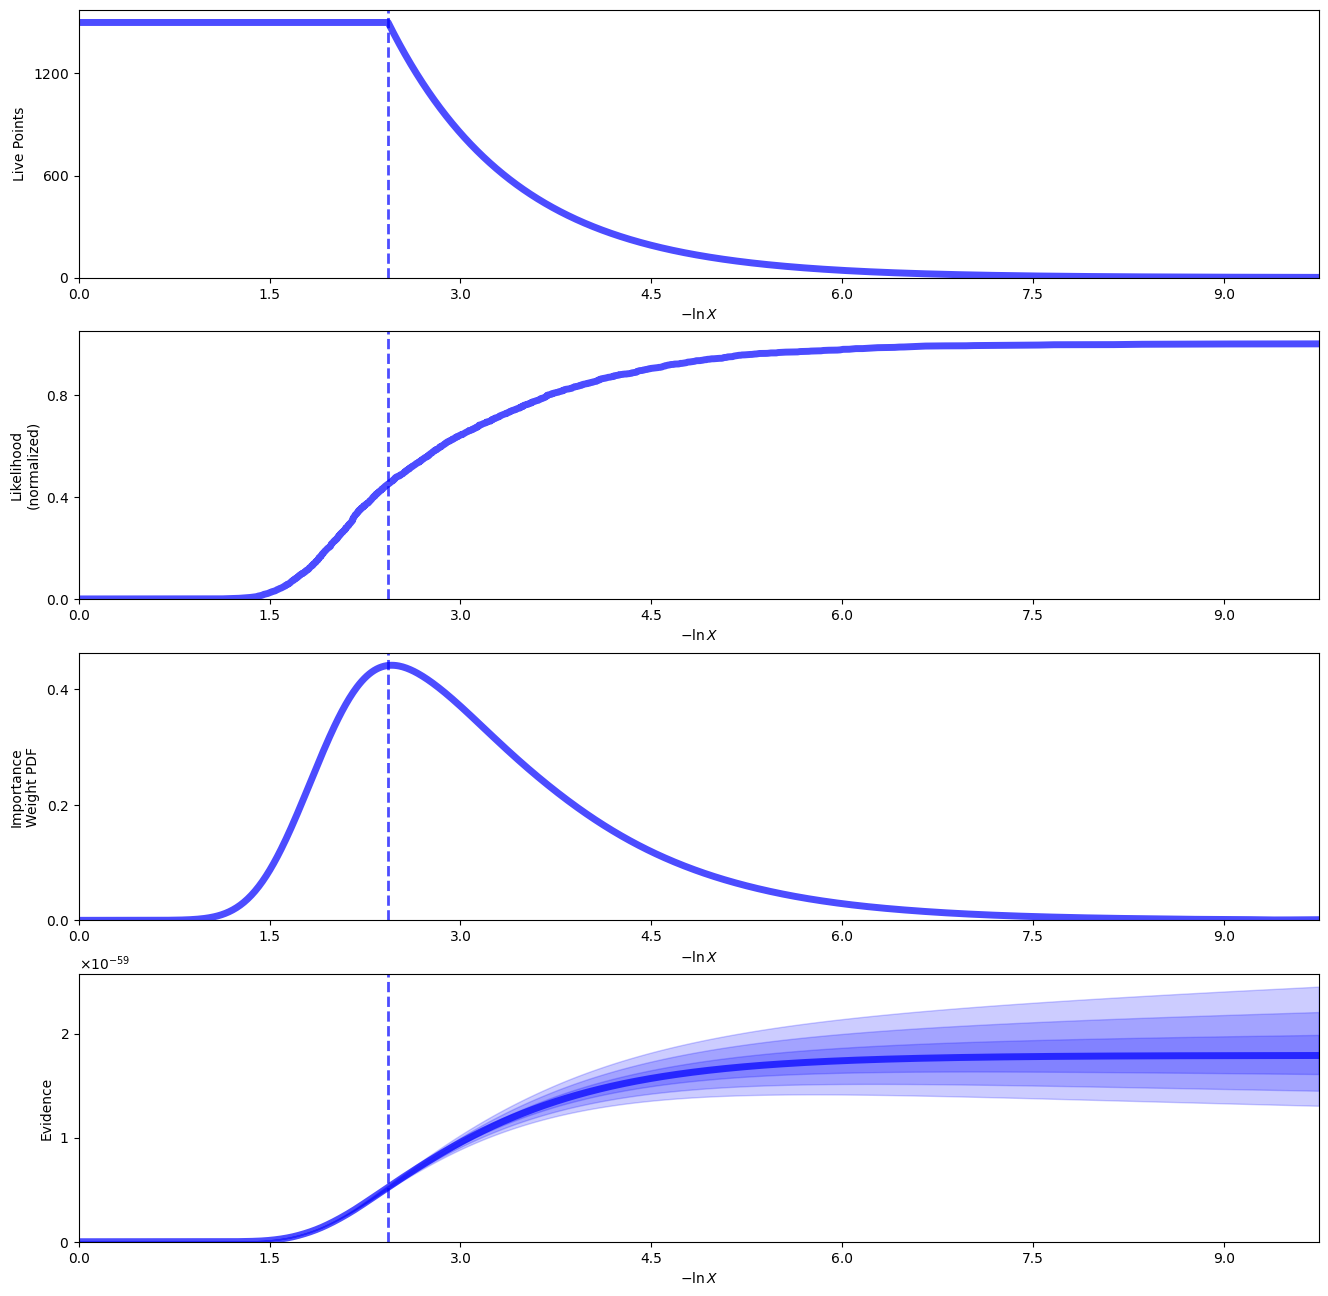

In [116]:
fig,axes = dyplot.runplot(results)

68% parameter credible regions are:
 [[0.22054973616066698, 0.7741382431632085], [60.29225496903439, 72.51078817548122]]

Mean and covariance of parameters are: [ 0.49341308 66.28857557]
[[ 0.06019432 -1.22598003]
 [-1.22598003 33.75433246]]
[[ 0.77822187 61.04824296]
 [ 0.30903168 69.6035095 ]
 [ 0.39884793 65.80349298]
 ...
 [ 0.73185662 56.79102242]
 [ 0.15647216 70.14048062]
 [ 0.54274135 63.24258694]]


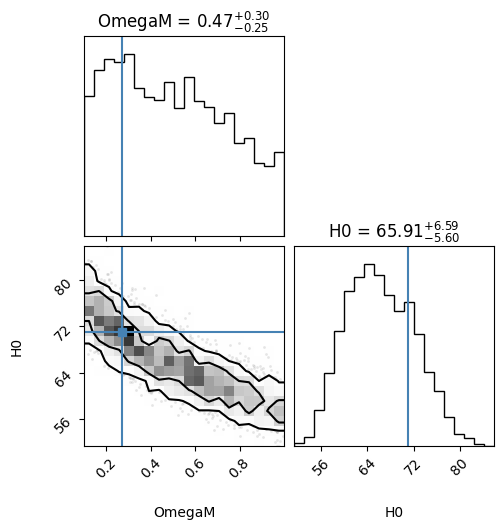

In [117]:
samples = results.samples  # samples
weights = np.exp(results.logwt - results.logz[-1])  


quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')


mean, cov = dyfunc.mean_and_cov(samples, weights)
print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))

samples_equal = dyfunc.resample_equal(samples, weights)

results_sim = dyfunc.resample_run(results)

fig = corner.corner(
    samples_equal, labels=["OmegaM","H0"], levels=[0.68,0.95], show_titles=True, truths=[0.27,71]
);

print(samples_equal)


/home/lorenzo/Desktop/repos/python_ambient/lib/python3.12/site-packages/astropy/cosmology/_src/flrw/base.py:1182: RuntimeWarning: divide by zero encountered in log10
  val = 5.0 * np.log10(abs(self.luminosity_distance(z).value)) + 25.0


(35.0, 50.0)

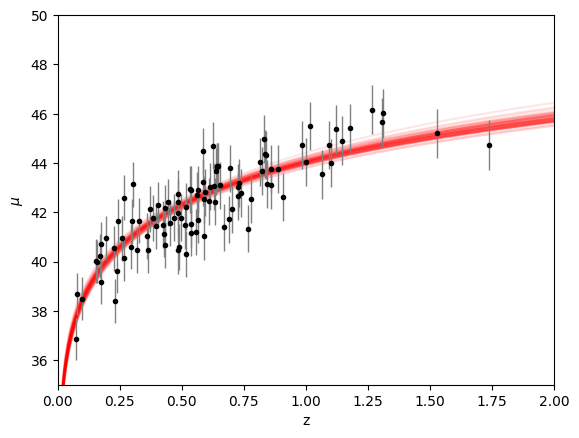

In [118]:
z = np.linspace(0, 2, 1000)
for OmegaM,H0, in samples_equal[::100]:
    #print(OmegaM, H0)
    mu_model = model(z,OmegaM,H0)
    #print(mu_model)
    plt.plot(z, mu_model,color='red',alpha=0.1)
    
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.xlim(0,2)
plt.ylim(35,50)
    

Adesso runniamo un nested sampling su un modello che ha OmegaM = 1, ovvero zero frazione di dark energy (prende il nome di modello di Einstein-De-Sitter)

In [90]:
def model_critical(z, H0):
    cosmo = LambdaCDM(H0 = H0, Om0 = 1, Ode0 = 0) #Omega dark energy Ode0
    return cosmo.distmod(z).value

def loglikelihood_critical(theta): 
    H0 = theta[0]
    m_model = model_critical(z_sample, H0)

    return np.sum(scipy.stats.norm(loc = m_model, scale = dmu).logpdf(mu_sample)) #la somma delle likelihood intese in modo gaussiano

#ora ho solo un parametro e dunque modifichiamo anche le prior
def ptform_critical(u):
    #facciamo delle prior uniformi, la H0 è stimata teoricamente tra 67 e 74 km/s * MegaParsec
    mins = np.array([30.])
    maxs = np.array([100.])
        
    return  mins + u*(maxs-mins)
    

In [92]:
ndims_critical = 1 #solo H0 è parametro

sampler_cr = dynesty.NestedSampler(loglikelihood_critical, ptform_critical, ndims_critical, nlive = 1500) #i live point sono i punti che scalano la likelihood
sampler_cr.run_nested()
results_cr = sampler_cr.results

3759it [03:37, 17.29it/s, +1500 | bound: 0 | nc: 1 | ncall: 20262 | eff(%): 28.030 | loglstar:   -inf < -133.530 <    inf | logz: -135.934 +/-    nan | dlogz:  0.001 >  1.509]


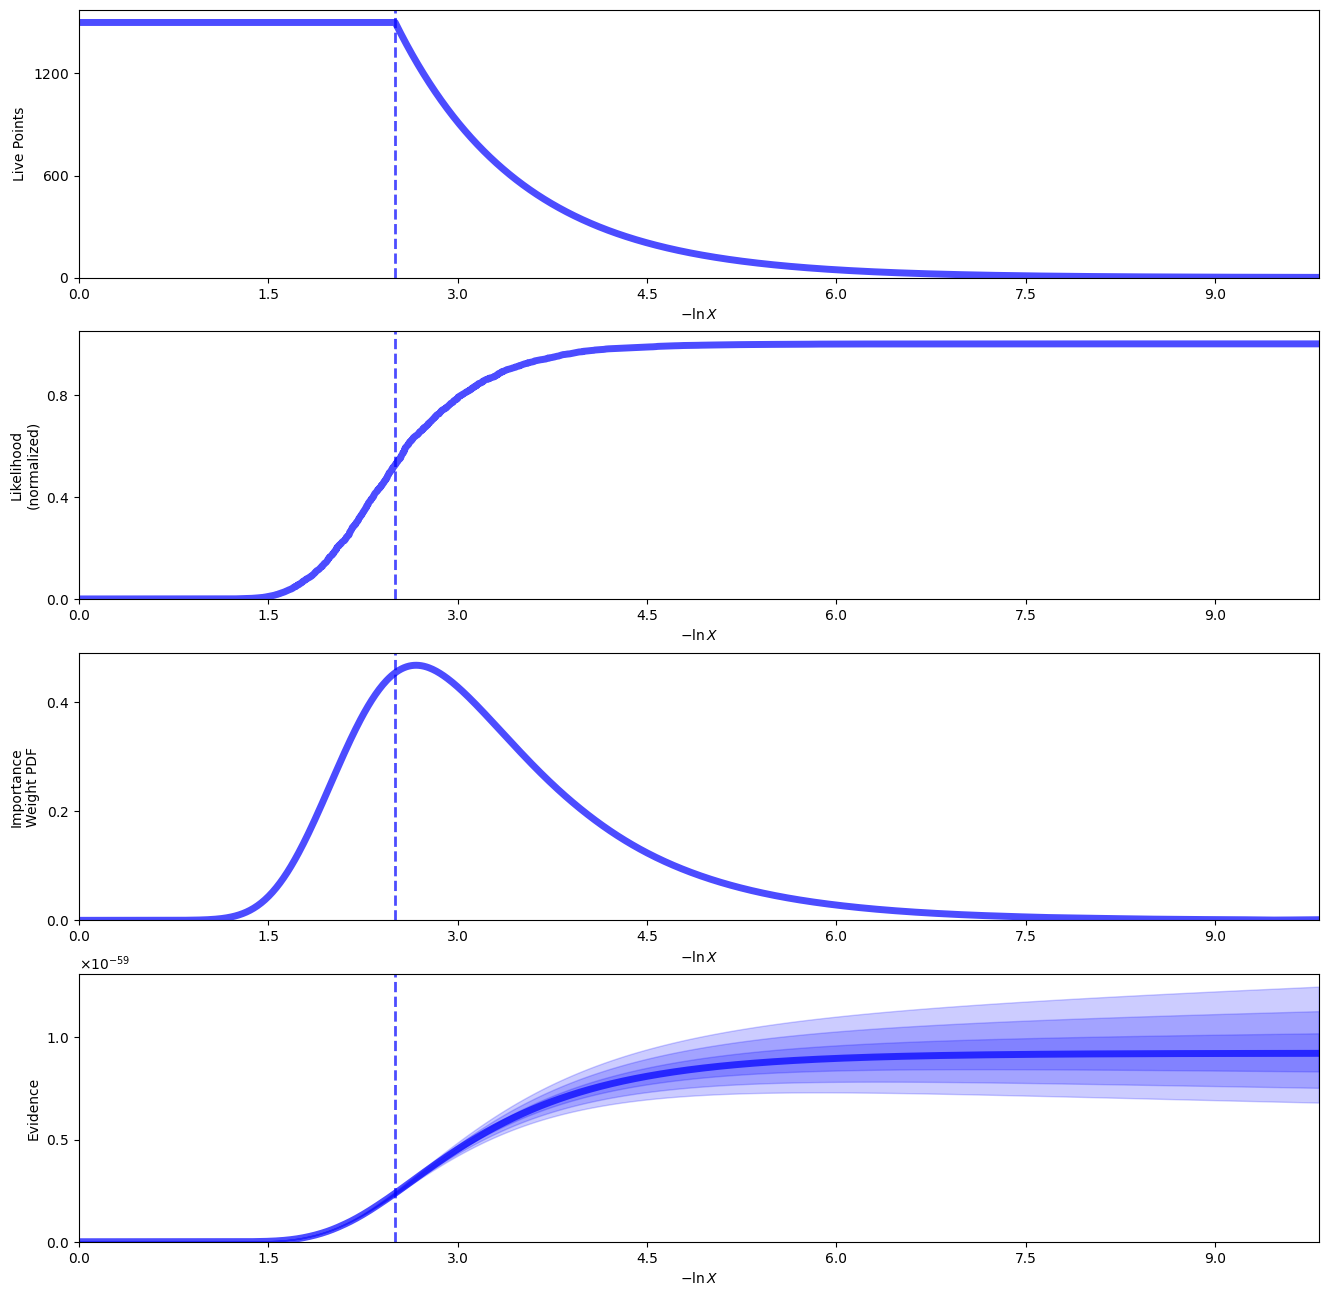

In [93]:
fig,axes = dyplot.runplot(results_cr)

68% parameter credible regions are:
 [[55.31341618221522, 60.21406971964407]]

Mean and covariance of parameters are: [57.73759898]
[[6.40280679]]


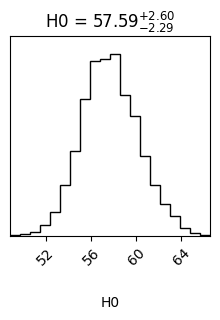

In [106]:
import arviz
samples_cr = results_cr.samples  # samples
weights_cr = np.exp(results_cr.logwt - results_cr.logz[-1])  


quantiles_cr = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights_cr)
             for samps in samples_cr.T]
print('68% parameter credible regions are:\n ' + str(quantiles_cr) + '\n')


mean_cr, cov_cr = dyfunc.mean_and_cov(samples_cr, weights_cr)
print('Mean and covariance of parameters are: ' + str(mean_cr) + '\n' + str(cov_cr))

#il resample per dare lo stesso peso a tutti i punti
samples_cr_equal = dyfunc.resample_equal(samples_cr, weights_cr)

results_sim_cr = dyfunc.resample_run(results_cr)

fig = corner.corner(
    samples_cr_equal, 
    labels=["H0"],          
    levels=[0.68, 0.95], 
    show_titles=True, 
    #truths=[71.]                 
)

ax = fig.axes[0]

usiamo le evidenze dei due nested sampling per computare il bayesian factor

In [119]:
logz_fac = sampler_cr.results.logz[-1] - sampler.results.logz[-1]
z_fac = np.exp(logz_fac)
print(z_fac)

0.5149391043893152


Il bayes factor viene 0.5 dunque non possiamo dire in modo confident quale modello sia il migliore. Proviamo con Savage-Dickey. Si prende il modello completo e si calcola la pdf del parametro omegaM in 1 

In [128]:
omega_m_samples = samples_equal[:, 0]
kde_om = KernelDensity(kernel='gaussian', bandwidth="silverman").fit(omega_m_samples[:,np.newaxis])
log_pdf_om = kde_om.score_samples(np.array([[1.0]]))
pdf_om = np.exp(log_pdf_om)[0]
omega_m_min = 0.0
omega_m_max = 1.0  
prior_at_1 = 1.0 / (omega_m_max - omega_m_min)
savage_dickey = pdf_om / prior_at_1
print(f"Savage-Dickey (Crit/Compl): {bayes_factor_sd:.4f}")

Savage-Dickey (Crit/Compl): 0.3925


Anche in questo caso, il ratio conferma debolmente l'ipotesi completa 